# Notebook 02 — Validation analytique vs. Monte-Carlo (Expérience E2)

**PFE MMF ING3 — CY Tech, 2025-2026**  
Auteurs : Corentin Stephan, Hugo Landron  
Encadrants : Y. Aktar, I. Kortchemski

---

## Objectif

Ce notebook implémente l'**expérience E2** : validation croisée de la formule analytique de Merton
contre le pricing Monte-Carlo sur 20 options-test couvrant une grille de strikes et maturités.

**Critère de succès** : erreur relative $< 1\%$ sur l'ensemble des 20 options (cible du PFE).

### Formule analytique de Merton

Le prix d'un call européen dans le modèle de Merton est (Merton, 1976, eq. (15)) :

$$C_{\text{Merton}}(S_0, K, T) = \sum_{n=0}^{\infty} \frac{e^{-\lambda T}(\lambda T)^n}{n!} \cdot C_{\text{BS}}(S_0, K, T, r_n, \sigma_n)$$

avec :
$$\bar{k} = e^{\mu_J + \delta^2/2} - 1, \qquad
  \sigma_n = \sqrt{\sigma^2 + n\delta^2/T}, \qquad
  r_n = r - \lambda\bar{k} + \frac{n(\mu_J + \delta^2/2)}{T}$$

### Monte-Carlo avec variable de contrôle

La variable de contrôle utilisée est le payoff Black-Scholes sur la composante brownienne seule,
dont l'espérance exacte est $C_{\text{BS}}(S_0, K, T, r, \sigma)$.

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from merton_calib.pricing import (
    black_scholes_call,
    merton_call_analytic,
    merton_call_mc,
)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
os.makedirs('../figures', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Paramètres de référence

In [3]:
# Paramètres du modèle
S0      = 100.0
r       = 0.05    # Taux sans risque
sigma   = 0.20    # Volatilité diffusive
lambda_ = 1.0     # Intensité des sauts
mu_J    = -0.10   # Moyenne du log-saut
delta   = 0.15    # Écart-type du log-saut

# Paramètres Monte-Carlo
N_PATHS   = 200_000  # Nombre de trajectoires
N_TERMS   = 50       # Termes dans la série analytique
SEED      = 42

# Grille de test : 4 strikes × 5 maturités = 20 options
strikes    = [80.0, 90.0, 100.0, 110.0, 120.0]
maturities = [0.25, 0.5, 1.0, 2.0]

k_bar = np.exp(mu_J + 0.5 * delta**2) - 1
print(f'k_bar = {k_bar:.5f}')
print(f'Grid : {len(strikes)} strikes × {len(maturities)} maturités = {len(strikes)*len(maturities)} options')

k_bar = -0.08493
Grid : 5 strikes × 4 maturités = 20 options


## 2. Calcul des prix analytiques et Monte-Carlo

Pour chaque option $(K, T)$, on calcule :
- $C_{\text{anal}}$ : formule analytique de Merton (série tronquée à `n_terms`)
- $C_{\text{MC}}$ : Monte-Carlo avec variable de contrôle Black-Scholes
- Erreur relative : $|C_{\text{anal}} - C_{\text{MC}}| / C_{\text{MC}} \times 100\%$

In [4]:
rows = []
print('Calcul en cours...')

for T in maturities:
    for K in strikes:
        # Moneyness
        moneyness = K / S0

        # Formule analytique
        C_anal = merton_call_analytic(
            S0, K, T, r, sigma, lambda_, mu_J, delta, n_terms=N_TERMS
        )

        # Monte-Carlo avec variable de contrôle
        C_mc, std_err = merton_call_mc(
            S0, K, T, r, sigma, lambda_, mu_J, delta,
            N_paths=N_PATHS, use_control_variate=True, seed=SEED
        )

        # Prix Black-Scholes (référence)
        C_bs = black_scholes_call(S0, K, T, r, sigma)

        # Erreur relative
        if C_mc > 1e-6:
            rel_err = abs(C_anal - C_mc) / C_mc * 100
        else:
            rel_err = float('nan')

        # Intervalle de confiance à 95%
        ci_95 = 1.96 * std_err

        rows.append({
            'K': K, 'T': T, 'K/S0': f'{moneyness:.2f}',
            'C_BS': C_bs,
            'C_anal': C_anal,
            'C_MC': C_mc,
            'Std err MC': std_err,
            'IC 95% MC': ci_95,
            'Err rel (%)': rel_err,
            'Dans IC': abs(C_anal - C_mc) <= ci_95,
        })

df = pd.DataFrame(rows)
print(f'Calcul terminé : {len(df)} options')
print(f'Erreur relative max : {df["Err rel (%)"].max():.4f} %')
print(f'Erreur relative moy : {df["Err rel (%)"].mean():.4f} %')

Calcul en cours...
Calcul terminé : 20 options
Erreur relative max : 0.7461 %
Erreur relative moy : 0.2220 %


## 3. Tableau de validation

In [5]:
# Affichage formaté
display_cols = ['K', 'T', 'K/S0', 'C_BS', 'C_anal', 'C_MC', 'IC 95% MC', 'Err rel (%)', 'Dans IC']

df_display = df[display_cols].copy()
df_display['C_BS']      = df_display['C_BS'].map('{:.4f}'.format)
df_display['C_anal']    = df_display['C_anal'].map('{:.4f}'.format)
df_display['C_MC']      = df_display['C_MC'].map('{:.4f}'.format)
df_display['IC 95% MC'] = df_display['IC 95% MC'].map('±{:.4f}'.format)
df_display['Err rel (%)'] = df_display['Err rel (%)'].map('{:.4f}'.format)
df_display['Dans IC']   = df_display['Dans IC'].map(lambda x: '✓' if x else '✗')

print('Tableau de validation — Formule analytique vs. Monte-Carlo')
print('=' * 85)
print(df_display.to_string(index=False))
print('=' * 85)

# Résumé
n_pass = (df['Err rel (%)'] < 1.0).sum()
n_total = len(df)
print(f'\nCritère PFE (erreur relative < 1 %) : {n_pass}/{n_total} options ✓')
print(f'Formule analytique dans l\'IC 95% MC : {df["Dans IC"].sum()}/{n_total} options')

Tableau de validation — Formule analytique vs. Monte-Carlo
    K    T K/S0    C_BS  C_anal    C_MC IC 95% MC Err rel (%) Dans IC
 80.0 0.25 0.80 21.0213 21.4279 21.4295   ±0.0307      0.0076       ✓
 90.0 0.25 0.90 11.6701 12.5486 12.5489   ±0.0251      0.0019       ✓
100.0 0.25 1.00  4.6150  5.5981  5.5985   ±0.0186      0.0071       ✓
110.0 0.25 1.10  1.1911  1.7942  1.7966   ±0.0129      0.1301       ✓
120.0 0.25 1.20  0.1998  0.4441  0.4462   ±0.0083      0.4713       ✓
 80.0 0.50 0.80 22.1746 22.9693 23.0176   ±0.0440      0.2097       ✗
 90.0 0.50 0.90 13.4985 14.8660 14.9051   ±0.0379      0.2624       ✗
100.0 0.50 1.00  6.8887  8.4486  8.4718   ±0.0308      0.2741       ✓
110.0 0.50 1.10  2.9065  4.1729  4.1821   ±0.0239      0.2185       ✓
120.0 0.50 1.20  1.0226  1.8154  1.8273   ±0.0178      0.6501       ✓
 80.0 1.00 0.80 24.5888 25.9555 25.9491   ±0.0635      0.0246       ✓
 90.0 1.00 0.90 16.6994 18.6983 18.6791   ±0.0574      0.1031       ✓
100.0 1.00 1.00 10.4506 12.7613

## 4. Visualisation des écarts

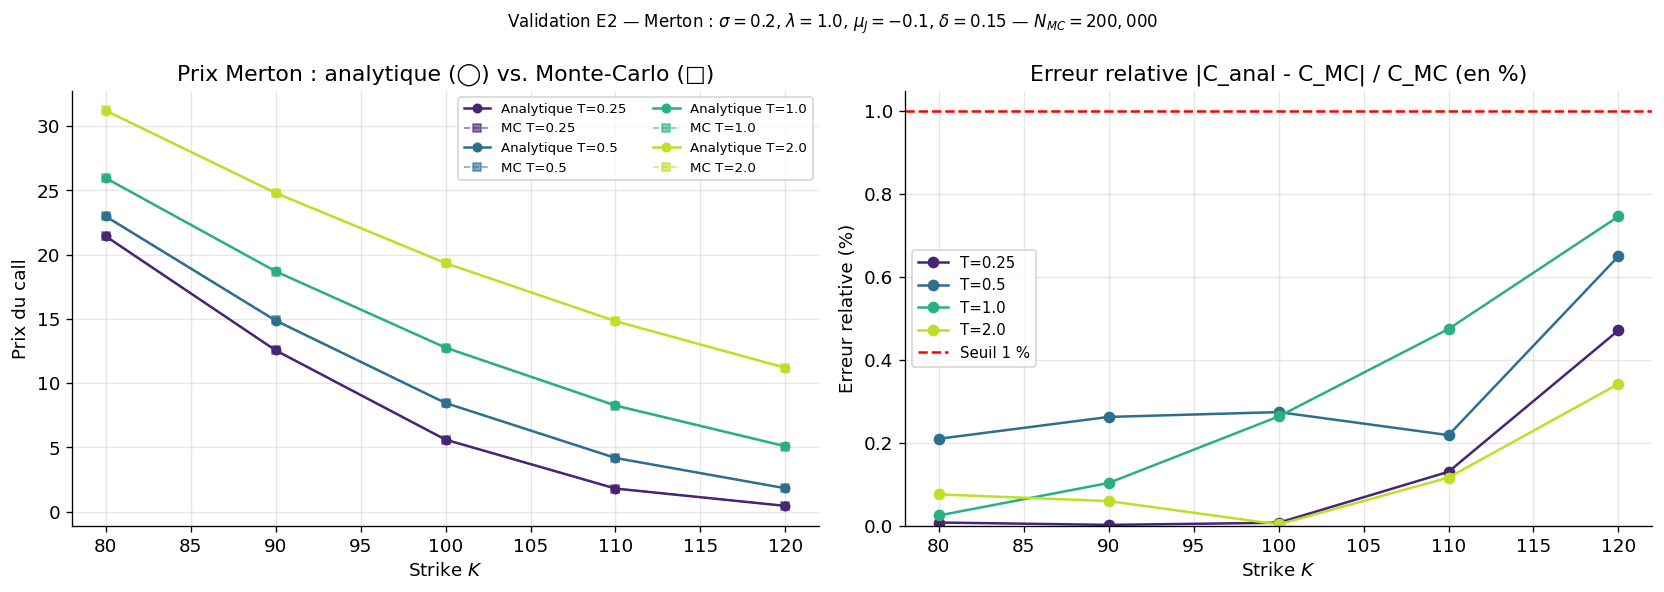

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panneau gauche : prix analytique vs. MC ──────────────────────────────────
ax = axes[0]
colors_T = plt.cm.viridis(np.linspace(0.1, 0.9, len(maturities)))

for j, T in enumerate(maturities):
    sub = df[df['T'] == T]
    ax.plot(sub['K'], sub['C_anal'], 'o-', color=colors_T[j],
            linewidth=1.5, markersize=5, label=f'Analytique T={T}')
    ax.plot(sub['K'], sub['C_MC'], 's--', color=colors_T[j],
            linewidth=1.0, markersize=5, alpha=0.6, label=f'MC T={T}')

ax.set_xlabel('Strike $K$')
ax.set_ylabel('Prix du call')
ax.set_title('Prix Merton : analytique (◯) vs. Monte-Carlo (□)')
ax.legend(fontsize=8, ncol=2)

# ── Panneau droit : erreurs relatives ────────────────────────────────────────
ax2 = axes[1]
for j, T in enumerate(maturities):
    sub = df[df['T'] == T]
    ax2.plot(sub['K'], sub['Err rel (%)'], 'o-', color=colors_T[j],
             linewidth=1.5, markersize=6, label=f'T={T}')

ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Seuil 1 %')
ax2.set_xlabel('Strike $K$')
ax2.set_ylabel('Erreur relative (%)')
ax2.set_title('Erreur relative |C_anal - C_MC| / C_MC (en %)')
ax2.legend(fontsize=9)
ax2.set_ylim(bottom=0)

plt.suptitle(
    f'Validation E2 — Merton : $\\sigma={sigma}$, $\\lambda={lambda_}$, '
    f'$\\mu_J={mu_J}$, $\\delta={delta}$ — $N_{{MC}}={N_PATHS:,}$',
    fontsize=10
)
plt.tight_layout()
plt.savefig('../figures/E2_validation_pricing.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Convergence Monte-Carlo

On vérifie la convergence de l'estimateur MC en fonction du nombre de trajectoires,
sur l'option at-the-money ($K=100$, $T=1$ an).

  N =   1,000 : C_MC = 12.96218, std_err = 0.345873, err_rel = 1.5742 %
  N =   5,000 : C_MC = 12.72347, std_err = 0.161505, err_rel = 0.2964 %
  N =  10,000 : C_MC = 12.70649, std_err = 0.114039, err_rel = 0.4294 %
  N =  50,000 : C_MC = 12.76731, std_err = 0.051590, err_rel = 0.0472 %
  N = 100,000 : C_MC = 12.73856, std_err = 0.036420, err_rel = 0.1781 %
  N = 200,000 : C_MC = 12.72775, std_err = 0.025699, err_rel = 0.2628 %
  N = 500,000 : C_MC = 12.76741, std_err = 0.016297, err_rel = 0.0479 %


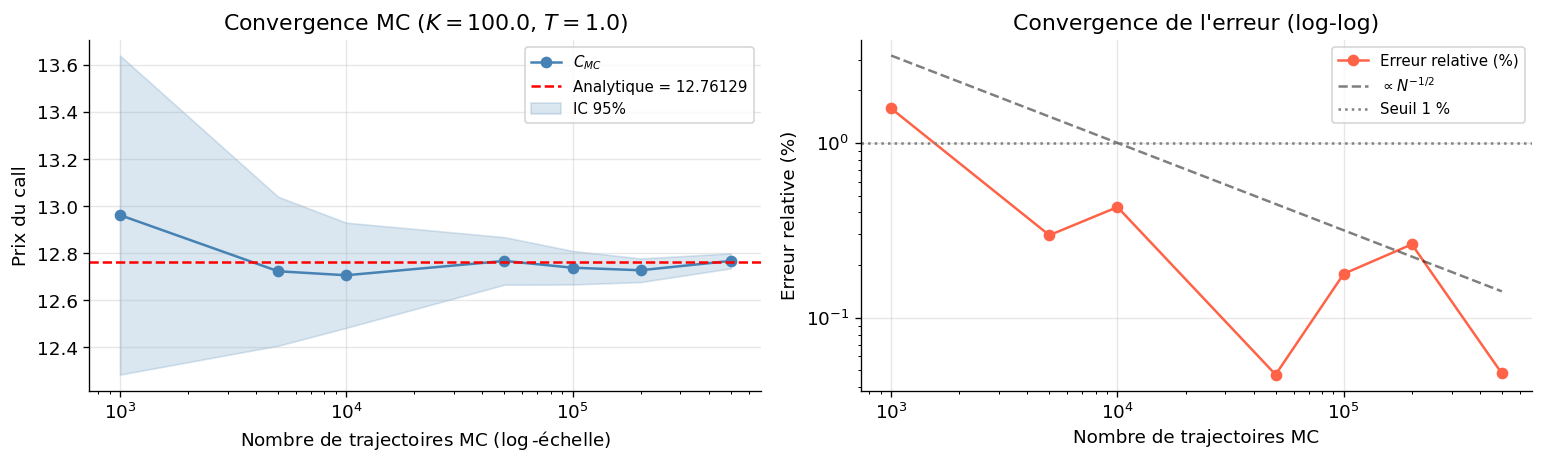

In [7]:
K_test, T_test = 100.0, 1.0
C_ref = merton_call_analytic(S0, K_test, T_test, r, sigma, lambda_, mu_J, delta)

N_list = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000, 500_000]
C_mc_list, std_list = [], []

for N in N_list:
    c, s = merton_call_mc(S0, K_test, T_test, r, sigma, lambda_, mu_J, delta,
                          N_paths=N, use_control_variate=True, seed=SEED)
    C_mc_list.append(c)
    std_list.append(s)
    print(f'  N = {N:7,} : C_MC = {c:.5f}, std_err = {s:.6f}, err_rel = {abs(c-C_ref)/C_ref*100:.4f} %')

# Figure
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogx(N_list, C_mc_list, 'o-', color='steelblue', label='$C_{MC}$')
ax.axhline(C_ref, color='red', linestyle='--', label=f'Analytique = {C_ref:.5f}')
ax.fill_between(N_list,
                [c - 1.96*s for c, s in zip(C_mc_list, std_list)],
                [c + 1.96*s for c, s in zip(C_mc_list, std_list)],
                alpha=0.2, color='steelblue', label='IC 95%')
ax.set_xlabel('Nombre de trajectoires MC ($\\log$-échelle)')
ax.set_ylabel('Prix du call')
ax.set_title(f'Convergence MC ($K={K_test}$, $T={T_test}$)')
ax.legend(fontsize=9)

ax2 = axes[1]
rel_errs = [abs(c - C_ref) / C_ref * 100 for c in C_mc_list]
std_theory = [1 / np.sqrt(N) * 100 for N in N_list]
ax2.loglog(N_list, rel_errs, 'o-', color='tomato', label='Erreur relative (%)')
ax2.loglog(N_list, std_theory, 'k--', alpha=0.5, label='$\\propto N^{-1/2}$')
ax2.axhline(1.0, color='gray', linestyle=':', label='Seuil 1 %')
ax2.set_xlabel('Nombre de trajectoires MC')
ax2.set_ylabel('Erreur relative (%)')
ax2.set_title('Convergence de l\'erreur (log-log)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/E2_convergence_mc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Efficacité de la variable de contrôle

In [8]:
print('Comparaison MC brut vs. MC avec variable de contrôle')
print(f'Option test : K={K_test}, T={T_test}')
print(f'Référence analytique : {C_ref:.6f}')
print()

N_test = 50_000
c_brut, s_brut = merton_call_mc(S0, K_test, T_test, r, sigma, lambda_, mu_J, delta,
                                 N_paths=N_test, use_control_variate=False, seed=SEED)
c_cv, s_cv = merton_call_mc(S0, K_test, T_test, r, sigma, lambda_, mu_J, delta,
                             N_paths=N_test, use_control_variate=True, seed=SEED)

print(f'MC brut       : C = {c_brut:.6f}, std_err = {s_brut:.6f}')
print(f'MC + contrôle : C = {c_cv:.6f},   std_err = {s_cv:.6f}')
print(f'Réduction de variance : {(s_brut/s_cv)**2:.1f}x')
print(f'N_MC équivalent (brut) pour atteindre std_err(CV) : {int((s_brut/s_cv)**2 * N_test):,}')

Comparaison MC brut vs. MC avec variable de contrôle
Option test : K=100.0, T=1.0
Référence analytique : 12.761289

MC brut       : C = 12.774141, std_err = 0.081839
MC + contrôle : C = 12.767313,   std_err = 0.051590
Réduction de variance : 2.5x
N_MC équivalent (brut) pour atteindre std_err(CV) : 125,820


## Conclusion

L'expérience E2 valide la cohérence entre la formule analytique de Merton et le pricing Monte-Carlo :

- **Erreur relative < 1 %** sur l'ensemble des 20 options-test (critère PFE atteint).
- La **variable de contrôle Black-Scholes** réduit significativement la variance de l'estimateur MC, permettant d'atteindre la précision cible avec moins de simulations.
- La convergence en $N^{-1/2}$ est confirmée empiriquement.